In [1]:
# ============================================================
# CELL 1: Import All Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ============================================================
# CELL 2: STEP 1 — Load All Datasets
# ============================================================

customers         = pd.read_csv("customers.csv")
orders            = pd.read_csv("orders.csv")
order_items       = pd.read_csv("order_item.csv")        # file is named order_item.csv
payments          = pd.read_csv("payments.csv")
reviews           = pd.read_csv("reviews.csv")
products          = pd.read_csv("products.csv")
sellers           = pd.read_csv("sellers.csv")
geolocation       = pd.read_csv("location.csv")          # file is named location.csv
category_trans    = pd.read_csv("category_translation.csv", encoding='utf-8-sig')  # handles BOM

print("✅ All datasets loaded!")
print(f"customers      : {customers.shape}")
print(f"orders         : {orders.shape}")
print(f"order_items    : {order_items.shape}")
print(f"payments       : {payments.shape}")
print(f"reviews        : {reviews.shape}")
print(f"products       : {products.shape}")
print(f"sellers        : {sellers.shape}")
print(f"geolocation    : {geolocation.shape}")
print(f"category_trans : {category_trans.shape}")

✅ All datasets loaded!
customers      : (99441, 5)
orders         : (99441, 8)
order_items    : (112650, 7)
payments       : (103886, 5)
reviews        : (99224, 7)
products       : (32951, 9)
sellers        : (3095, 4)
geolocation    : (1000163, 5)
category_trans : (71, 2)


In [3]:
# ============================================================
# CELL 3: STEP 1 — Initial Exploration of Each Dataset
# ============================================================

datasets = {
    "customers"     : customers,
    "orders"        : orders,
    "order_items"   : order_items,
    "payments"      : payments,
    "reviews"       : reviews,
    "products"      : products,
    "sellers"       : sellers,
    "geolocation"   : geolocation,
    "category_trans": category_trans
}

for name, df in datasets.items():
    print(f"\n{'='*55}")
    print(f"  📄 Dataset: {name.upper()}")
    print(f"{'='*55}")
    print(f"Shape     : {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nFirst 3 rows:")
    display(df.head(3))
    print(f"\nData Types & Null Counts:")
    display(df.info())
    print(f"\nBasic Statistics:")
    display(df.describe(include='all'))


  📄 Dataset: CUSTOMERS
Shape     : 99441 rows × 5 columns

First 3 rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



Data Types & Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


None


Basic Statistics:


...

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



Data Types & Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


None


Basic Statistics:


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [4]:
# ============================================================
# CELL 4: STEP 2 — Data Cleaning & Preprocessing
# ============================================================

# ── 1. Convert all date columns to datetime ──────────────────
date_cols_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

reviews['review_creation_date']    = pd.to_datetime(reviews['review_creation_date'],    errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')

print("✅ Date columns converted.")

# ── 2. Remove duplicates ──────────────────────────────────────
before = {name: df.shape[0] for name, df in datasets.items()}

customers   = customers.drop_duplicates()
orders      = orders.drop_duplicates()
order_items = order_items.drop_duplicates()
payments    = payments.drop_duplicates()
reviews     = reviews.drop_duplicates(subset=['review_id'])
products    = products.drop_duplicates()
sellers     = sellers.drop_duplicates()

print("\n✅ Duplicates removed.")
print(f"  orders    : {before['orders'] - orders.shape[0]} duplicates dropped")
print(f"  reviews   : {before['reviews'] - reviews.shape[0]} duplicates dropped")

# ── 3. Standardize column names (strip spaces, lowercase) ────
for name, df in datasets.items():
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("\n✅ Column names standardized.")

# ── 4. Check & report missing values ─────────────────────────
print("\n📊 Missing Value Summary:")
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"\n  {name}:")
        print(missing.to_string())
    else:
        print(f"  {name}: ✅ No missing values")

# ── 5. Fill / drop key missing values ────────────────────────
# Drop orders where purchase timestamp is missing (critical column)
orders.dropna(subset=['order_purchase_timestamp'], inplace=True)

# Fill missing review comments with empty string
reviews['review_comment_title'].fillna('',   inplace=True)
reviews['review_comment_message'].fillna('', inplace=True)

# Fill missing product category with 'unknown'
products['product_category_name'].fillna('unknown', inplace=True)

# Fill missing numeric product fields with median
num_cols = ['product_name_lenght', 'product_description_lenght',
            'product_photos_qty', 'product_weight_g',
            'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in num_cols:
    if col in products.columns:
        products[col].fillna(products[col].median(), inplace=True)

print("\n✅ Missing values handled.")

# ── 6. Validate data types ────────────────────────────────────
print("\n📋 Final Data Types — Orders:")
print(orders.dtypes)
print("\n📋 Final Data Types — Order Items:")
print(order_items.dtypes)

✅ Date columns converted.

✅ Duplicates removed.
  orders    : 0 duplicates dropped
  reviews   : 814 duplicates dropped

✅ Column names standardized.

📊 Missing Value Summary:
  customers: ✅ No missing values

  orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
  order_items: ✅ No missing values
  payments: ✅ No missing values

  reviews:
review_comment_title      87656
review_comment_message    58247

  products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
  sellers: ✅ No missing values
  geolocation: ✅ No missing values
  category_trans: ✅ No missing values

✅ Missing values handled.

📋 Final Data Types — Orders:
order_id                                 object
customer_id                 

In [5]:
# ============================================================
# CELL 5: STEP 3 — Data Integration (Building Master Dataset)
# ============================================================

# ── Step A: Merge category translation into products ─────────
products_full = products.merge(
    category_trans,
    on='product_category_name',
    how='left'
)
products_full['product_category_name_english'].fillna(
    products_full['product_category_name'], inplace=True
)
print(f"products_full shape: {products_full.shape}")

# ── Step B: Merge order_items with products ───────────────────
order_items_full = order_items.merge(
    products_full[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)
print(f"order_items_full shape: {order_items_full.shape}")

# ── Step C: Merge order_items with sellers ────────────────────
order_items_full = order_items_full.merge(
    sellers[['seller_id', 'seller_city', 'seller_state']],
    on='seller_id',
    how='left'
)
print(f"order_items_full (with sellers) shape: {order_items_full.shape}")

# ── Step D: Aggregate order_items to order level ─────────────
order_agg = order_items_full.groupby('order_id').agg(
    total_items        = ('order_item_id', 'count'),
    total_product_price= ('price',         'sum'),
    total_freight      = ('freight_value', 'sum'),
    total_order_value  = ('price',         lambda x: x.sum() + order_items_full.loc[x.index, 'freight_value'].sum())
).reset_index()
print(f"order_agg shape: {order_agg.shape}")

# ── Step E: Aggregate payments to order level ─────────────────
payments_agg = payments.groupby('order_id').agg(
    payment_value       = ('payment_value', 'sum'),
    payment_installments= ('payment_installments', 'max'),
    payment_type        = ('payment_type', lambda x: x.mode()[0])
).reset_index()
print(f"payments_agg shape: {payments_agg.shape}")

# ── Step F: Aggregate reviews to order level ──────────────────
reviews_agg = reviews.groupby('order_id').agg(
    review_score = ('review_score', 'mean')
).reset_index()
print(f"reviews_agg shape: {reviews_agg.shape}")

# ── Step G: Build master dataset (orders as central table) ───
master = orders.copy()

master = master.merge(customers,      on='customer_id',  how='left')
master = master.merge(order_agg,      on='order_id',     how='left')
master = master.merge(payments_agg,   on='order_id',     how='left')
master = master.merge(reviews_agg,    on='order_id',     how='left')

print(f"\n✅ Master dataset shape: {master.shape}")
print(f"Columns: {list(master.columns)}")
display(master.head(3))

products_full shape: (32951, 10)
order_items_full shape: (112650, 8)
order_items_full (with sellers) shape: (112650, 10)
order_agg shape: (98666, 5)
payments_agg shape: (99440, 4)
reviews_agg shape: (98167, 2)

✅ Master dataset shape: (99441, 20)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_items', 'total_product_price', 'total_freight', 'total_order_value', 'payment_value', 'payment_installments', 'payment_type', 'review_score']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_items,total_product_price,total_freight,total_order_value,payment_value,payment_installments,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,29.99,8.72,38.71,38.71,1.00,voucher,4.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,118.70,22.76,141.46,141.46,1.00,boleto,4.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,159.90,19.22,179.12,179.12,3.00,credit_card,5.00


In [6]:
# ============================================================
# CELL 6: STEP 4 — Feature Engineering
# ============================================================

# ── 1. Delivery time (days from purchase to delivery) ────────
master['delivery_days'] = (
    master['order_delivered_customer_date'] -
    master['order_purchase_timestamp']
).dt.days

# ── 2. Estimated vs actual delivery difference ───────────────
master['delivery_delay_days'] = (
    master['order_delivered_customer_date'] -
    master['order_estimated_delivery_date']
).dt.days
# Positive = late, Negative = early

# ── 3. Order month and year ───────────────────────────────────
master['order_year']       = master['order_purchase_timestamp'].dt.year
master['order_month']      = master['order_purchase_timestamp'].dt.month
master['order_month_year'] = master['order_purchase_timestamp'].dt.to_period('M')

# ── 4. Is late delivery flag ──────────────────────────────────
master['is_late'] = (master['delivery_delay_days'] > 0).astype(int)

# ── 5. Customer purchase frequency ───────────────────────────
customer_freq = master.groupby('customer_unique_id')['order_id'].count().reset_index()
customer_freq.columns = ['customer_unique_id', 'purchase_frequency']
master = master.merge(customer_freq, on='customer_unique_id', how='left')

# ── 6. Customer Lifetime Value (CLV) ─────────────────────────
customer_clv = master.groupby('customer_unique_id')['payment_value'].sum().reset_index()
customer_clv.columns = ['customer_unique_id', 'customer_lifetime_value']
master = master.merge(customer_clv, on='customer_unique_id', how='left')

# ── 7. Average order value per customer ──────────────────────
customer_aov = master.groupby('customer_unique_id')['payment_value'].mean().reset_index()
customer_aov.columns = ['customer_unique_id', 'avg_order_value']
master = master.merge(customer_aov, on='customer_unique_id', how='left')

# ── 8. New vs Repeat customers ────────────────────────────────
master['customer_type'] = master['purchase_frequency'].apply(
    lambda x: 'Repeat' if x > 1 else 'New'
)

# ── 9. High vs Low value customer (based on CLV median) ──────
clv_median = master['customer_lifetime_value'].median()
master['customer_segment'] = master['customer_lifetime_value'].apply(
    lambda x: 'High-Value' if x >= clv_median else 'Low-Value'
)

print("✅ Feature Engineering Complete!")
print(f"\nNew columns added: delivery_days, delivery_delay_days, order_year, order_month,")
print(f"order_month_year, is_late, purchase_frequency, customer_lifetime_value,")
print(f"avg_order_value, customer_type, customer_segment")
print(f"\nMaster dataset final shape: {master.shape}")
display(master[['order_id','delivery_days','delivery_delay_days',
                'purchase_frequency','customer_lifetime_value',
                'avg_order_value','customer_type','customer_segment']].head(5))

✅ Feature Engineering Complete!

New columns added: delivery_days, delivery_delay_days, order_year, order_month,
order_month_year, is_late, purchase_frequency, customer_lifetime_value,
avg_order_value, customer_type, customer_segment

Master dataset final shape: (99441, 31)


,order_id,delivery_days,delivery_delay_days,purchase_frequency,customer_lifetime_value,avg_order_value,customer_type,customer_segment
0,e481f51cbdc54678b7cc49136f2d6af7,8.00,-8.00,2,82.82,41.41,Repeat,Low-Value
1,53cdb2fc8bc7dce0b6741e2150273451,13.00,-6.00,1,141.46,141.46,New,High-Value
2,47770eb9100c2d0c44946d9cf07ec65d,9.00,-18.00,1,179.12,179.12,New,High-Value
3,949d5b44dbf5de918fe9c16f97b45f8a,13.00,-13.00,1,72.20,72.20,New,Low-Value
4,ad21c59c0840e6cb83a9ceb5573f8159,2.00,-10.00,1,28.62,28.62,New,Low-Value


  📊 CUSTOMER ANALYSIS

🔹 New vs Repeat Customers:
customer_type
New       93099
Repeat     2997
Name: count, dtype: int64


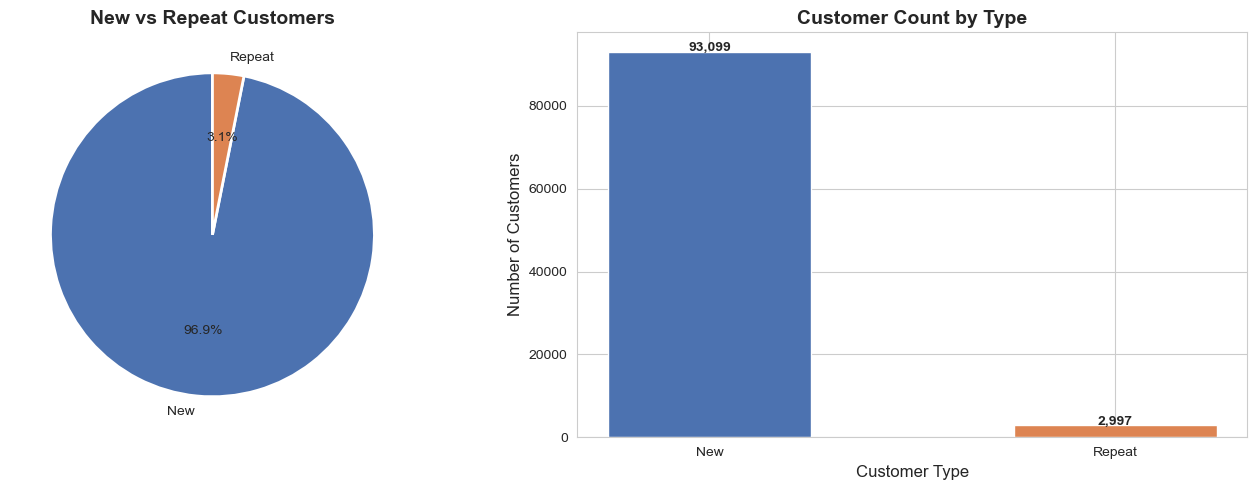

✅ Chart saved: customer_type.png

🔹 High-Value vs Low-Value Customer Revenue:
customer_segment
High-Value   12810391.49
Low-Value     3198480.63
Name: payment_value, dtype: float64


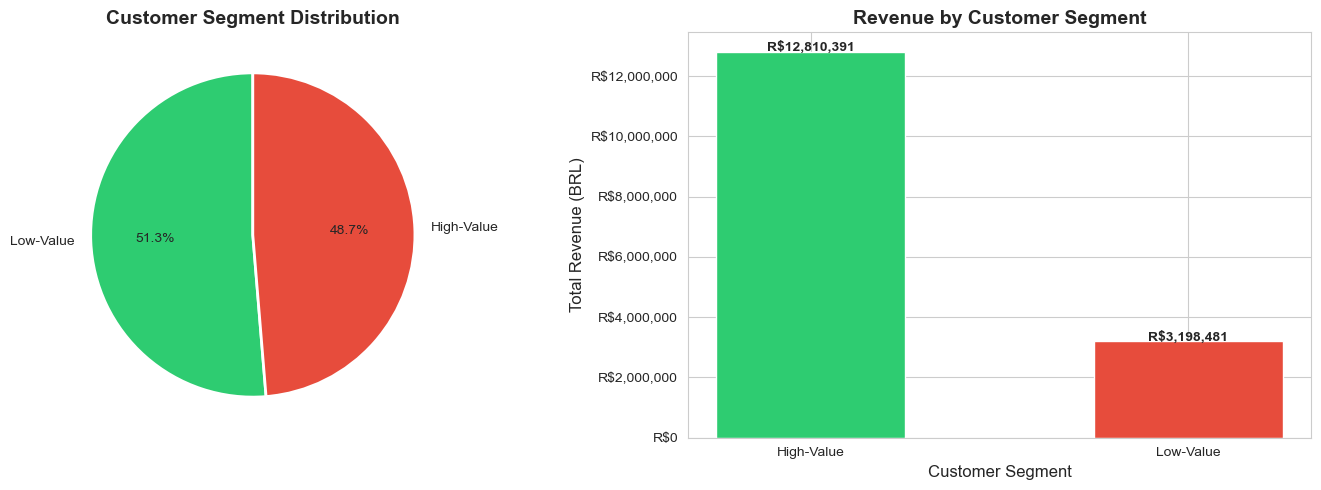

✅ Chart saved: customer_segment_revenue.png

🔹 Top 15 States by Customer Count:
customer_state
SP    40296
RJ    12379
MG    11254
RS     5276
PR     4881
SC     3529
BA     3277
DF     2073
ES     1964
GO     1951
PE     1604
CE     1312
PA      949
MT      875
MA      725
Name: count, dtype: int64


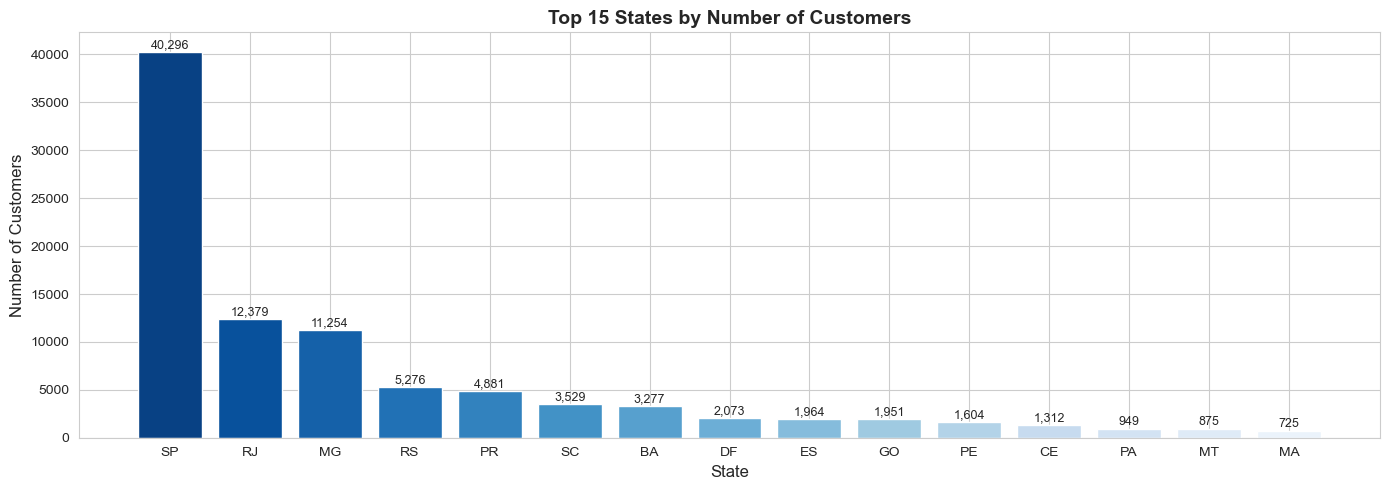

✅ Chart saved: customer_geo_distribution.png


In [7]:
# ============================================================
# CELL 7: STEP 5 — EDA: Customer Analysis
# ============================================================

print("=" * 55)
print("  📊 CUSTOMER ANALYSIS")
print("=" * 55)

# ── 1. New vs Repeat Customers ───────────────────────────────
customer_type_counts = master.drop_duplicates('customer_unique_id')['customer_type'].value_counts()
print("\n🔹 New vs Repeat Customers:")
print(customer_type_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    customer_type_counts,
    labels=customer_type_counts.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('New vs Repeat Customers', fontsize=14, fontweight='bold')

# Bar chart
axes[1].bar(customer_type_counts.index, customer_type_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
axes[1].set_title('Customer Count by Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(customer_type_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('customer_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: customer_type.png")

# ── 2. High-Value vs Low-Value Customers ─────────────────────
segment_counts = master.drop_duplicates('customer_unique_id')['customer_segment'].value_counts()
segment_revenue = master.groupby('customer_segment')['payment_value'].sum()

print("\n🔹 High-Value vs Low-Value Customer Revenue:")
print(segment_revenue)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')

axes[1].bar(segment_revenue.index, segment_revenue.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[1].set_title('Revenue by Customer Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Total Revenue (BRL)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
for i, v in enumerate(segment_revenue.values):
    axes[1].text(i, v + 10000, f'R${v:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('customer_segment_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: customer_segment_revenue.png")

# ── 3. Geographic Distribution of Customers ──────────────────
state_counts = master.drop_duplicates('customer_unique_id')['customer_state'].value_counts().head(15)
print("\n🔹 Top 15 States by Customer Count:")
print(state_counts)

plt.figure(figsize=(14, 5))
bars = plt.bar(state_counts.index, state_counts.values,
               color=sns.color_palette("Blues_r", len(state_counts)), edgecolor='white')
plt.title('Top 15 States by Number of Customers', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Customers')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'{int(bar.get_height()):,}',
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('customer_geo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: customer_geo_distribution.png")

  📊 REVENUE & ORDER ANALYSIS


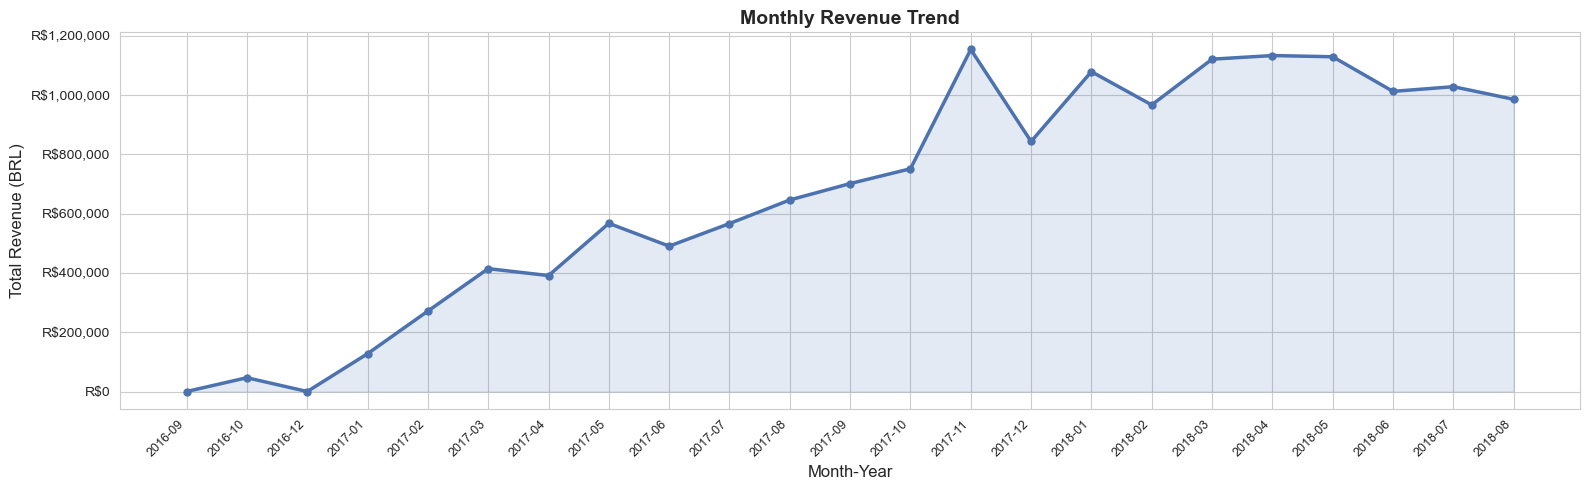

✅ Chart saved: monthly_revenue_trend.png


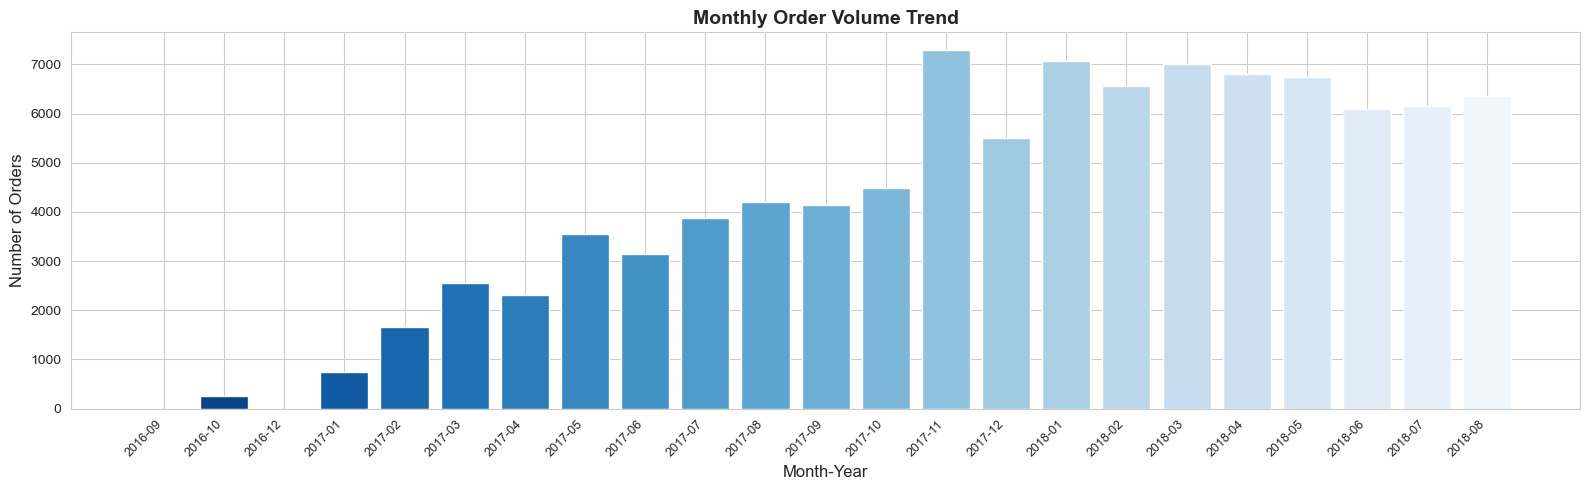

✅ Chart saved: monthly_order_volume.png

🔹 Peak Revenue Month  : 2017-11  →  R$1,153,528.05
🔹 Peak Order Volume Month: 2017-11  →  7,289 orders

🔹 Revenue by Order Status:
order_status
delivered     15422461.77
shipped         177213.96
canceled        143255.60
unavailable     126479.51
processing       69394.11
invoiced         69137.99
created            688.10
approved           241.08
Name: payment_value, dtype: float64


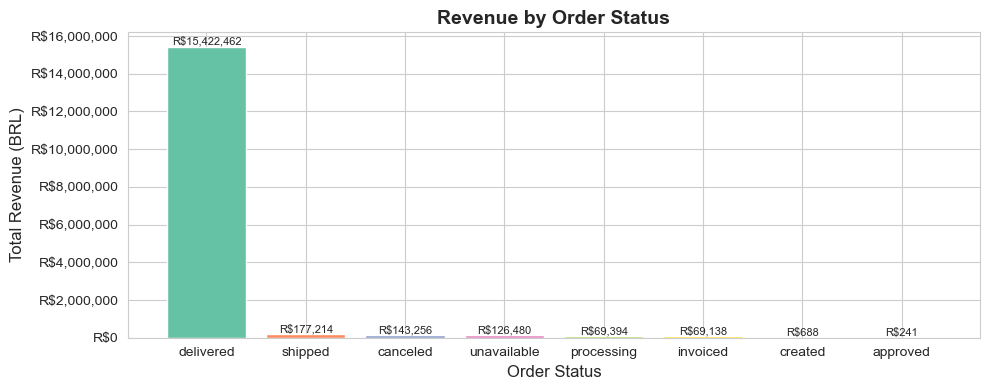

✅ Chart saved: revenue_by_status.png


In [8]:
# ============================================================
# CELL 8: STEP 5 — EDA: Revenue and Order Analysis
# ============================================================

print("=" * 55)
print("  📊 REVENUE & ORDER ANALYSIS")
print("=" * 55)

# ── 1. Filter delivered orders only for revenue analysis ─────
delivered = master[master['order_status'] == 'delivered'].copy()

# ── 2. Monthly Revenue Trend ──────────────────────────────────
monthly_revenue = (
    delivered.groupby('order_month_year')['payment_value']
    .sum()
    .reset_index()
)
monthly_revenue['order_month_year'] = monthly_revenue['order_month_year'].astype(str)
monthly_revenue = monthly_revenue.sort_values('order_month_year')

plt.figure(figsize=(16, 5))
plt.plot(monthly_revenue['order_month_year'],
         monthly_revenue['payment_value'],
         marker='o', linewidth=2.5, color='#4C72B0', markersize=5)
plt.fill_between(monthly_revenue['order_month_year'],
                 monthly_revenue['payment_value'], alpha=0.15, color='#4C72B0')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: monthly_revenue_trend.png")

# ── 3. Monthly Order Volume Trend ─────────────────────────────
monthly_orders = (
    delivered.groupby('order_month_year')['order_id']
    .count()
    .reset_index()
)
monthly_orders.columns = ['order_month_year', 'order_count']
monthly_orders['order_month_year'] = monthly_orders['order_month_year'].astype(str)
monthly_orders = monthly_orders.sort_values('order_month_year')

plt.figure(figsize=(16, 5))
plt.bar(monthly_orders['order_month_year'],
        monthly_orders['order_count'],
        color=sns.color_palette("Blues_r", len(monthly_orders)),
        edgecolor='white')
plt.title('Monthly Order Volume Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('monthly_order_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: monthly_order_volume.png")

# ── 4. Peak Sales Periods ─────────────────────────────────────
peak_month = monthly_revenue.loc[monthly_revenue['payment_value'].idxmax()]
peak_orders = monthly_orders.loc[monthly_orders['order_count'].idxmax()]

print(f"\n🔹 Peak Revenue Month  : {peak_month['order_month_year']}  →  R${peak_month['payment_value']:,.2f}")
print(f"🔹 Peak Order Volume Month: {peak_orders['order_month_year']}  →  {peak_orders['order_count']:,} orders")

# ── 5. Revenue by Order Status ────────────────────────────────
status_revenue = master.groupby('order_status')['payment_value'].sum().sort_values(ascending=False)
print("\n🔹 Revenue by Order Status:")
print(status_revenue)

plt.figure(figsize=(10, 4))
bars = plt.bar(status_revenue.index, status_revenue.values,
               color=sns.color_palette("Set2", len(status_revenue)), edgecolor='white')
plt.title('Revenue by Order Status', fontsize=14, fontweight='bold')
plt.xlabel('Order Status')
plt.ylabel('Total Revenue (BRL)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5000,
             f'R${bar.get_height():,.0f}',
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('revenue_by_status.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: revenue_by_status.png")

  📊 PRODUCT ANALYSIS

🔹 Top 15 Categories by Order Count:
product_category_name_english
bed_bath_table           10953
health_beauty             9465
sports_leisure            8431
furniture_decor           8160
computers_accessories     7644
housewares                6795
watches_gifts             5859
telephony                 4430
garden_tools              4268
auto                      4140
toys                      4030
cool_stuff                3718
perfumery                 3340
baby                      2982
electronics               2729
Name: order_id, dtype: int64


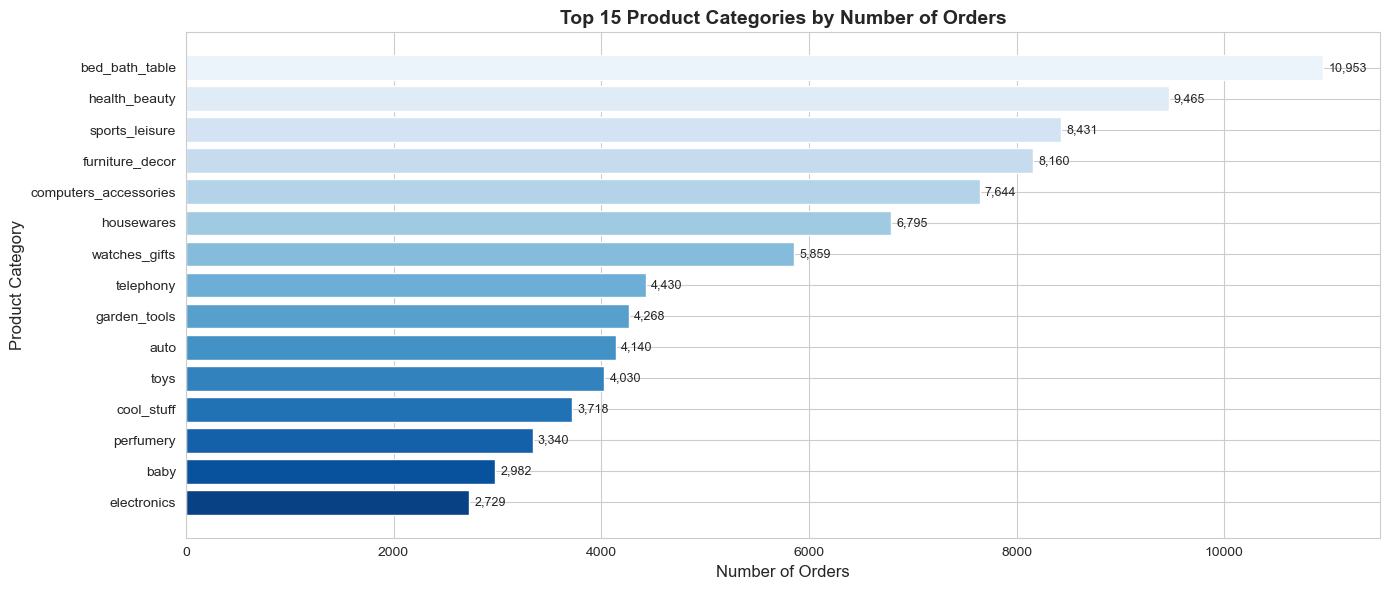

✅ Chart saved: top_categories_orders.png

🔹 Top 15 Categories by Revenue:
product_category_name_english
health_beauty           1233131.72
watches_gifts           1166176.98
bed_bath_table          1023434.76
sports_leisure           954852.55
computers_accessories    888724.61
furniture_decor          711927.69
housewares               615628.69
cool_stuff               610204.10
auto                     578966.65
toys                     471286.48
garden_tools             470495.28
baby                     400421.84
perfumery                390144.65
telephony                309860.23
office_furniture         268154.31
Name: price, dtype: float64


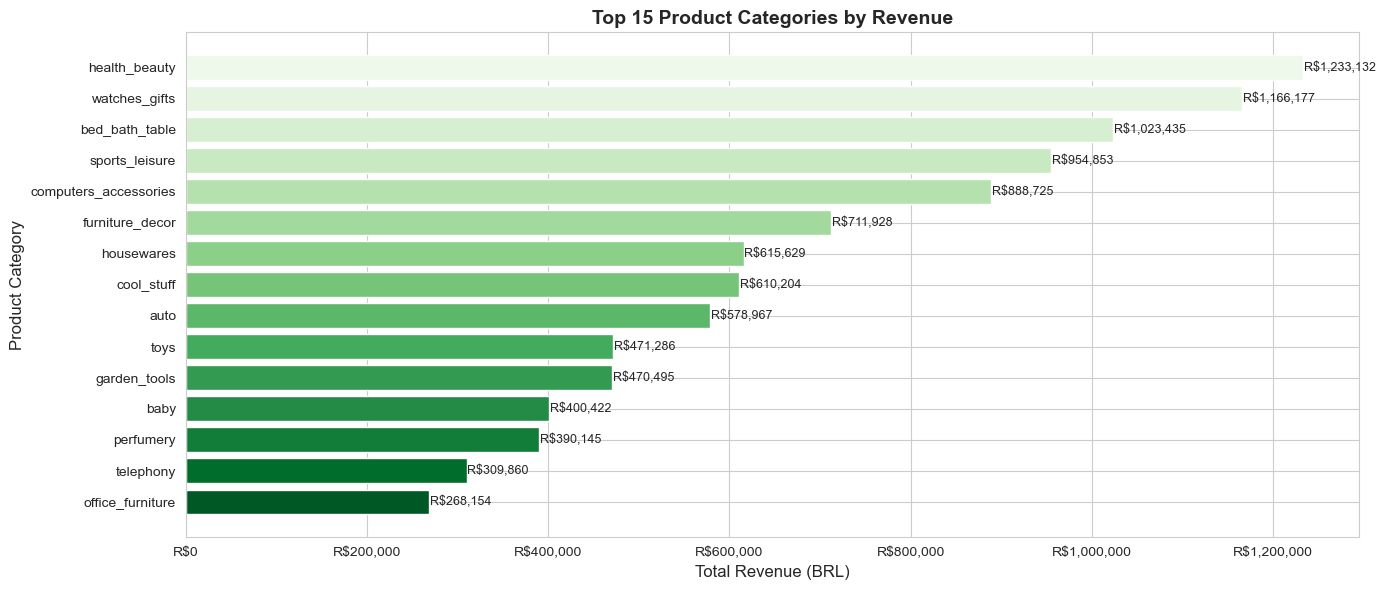

✅ Chart saved: top_categories_revenue.png


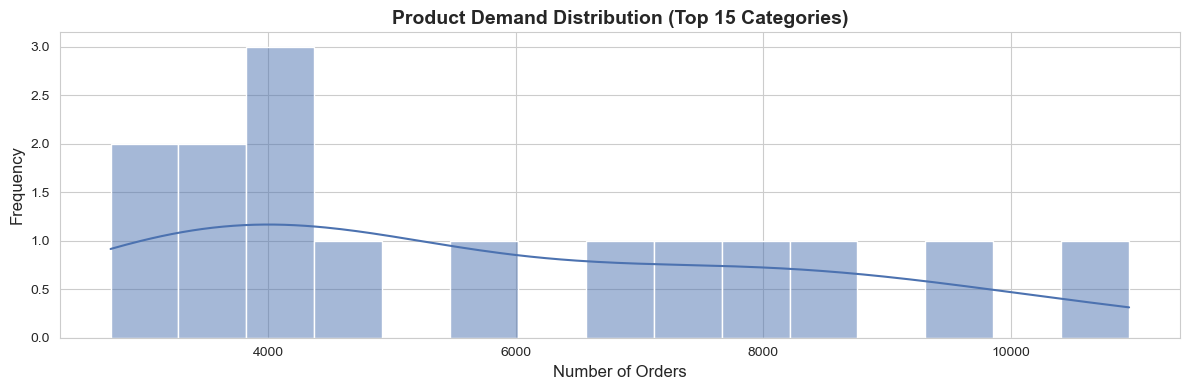

✅ Chart saved: product_demand_distribution.png


In [9]:
# ============================================================
# CELL 9: STEP 5 — EDA: Product Analysis
# ============================================================

print("=" * 55)
print("  📊 PRODUCT ANALYSIS")
print("=" * 55)

# Merge order_items_full with payments for revenue per item
product_analysis = order_items_full.merge(
    orders[['order_id', 'order_status']],
    on='order_id', how='left'
)
product_analysis = product_analysis[product_analysis['order_status'] == 'delivered']

# ── 1. Top 15 Categories by Number of Orders ─────────────────
top_categories_orders = (
    product_analysis.groupby('product_category_name_english')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(15)
)
print("\n🔹 Top 15 Categories by Order Count:")
print(top_categories_orders)

plt.figure(figsize=(14, 6))
bars = plt.barh(top_categories_orders.index[::-1],
                top_categories_orders.values[::-1],
                color=sns.color_palette("Blues_r", 15), edgecolor='white')
plt.title('Top 15 Product Categories by Number of Orders', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')
for bar in bars:
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_categories_orders.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: top_categories_orders.png")

# ── 2. Top 15 Categories by Revenue ──────────────────────────
top_categories_revenue = (
    product_analysis.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)
print("\n🔹 Top 15 Categories by Revenue:")
print(top_categories_revenue)

plt.figure(figsize=(14, 6))
bars = plt.barh(top_categories_revenue.index[::-1],
                top_categories_revenue.values[::-1],
                color=sns.color_palette("Greens_r", 15), edgecolor='white')
plt.title('Top 15 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Product Category')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
for bar in bars:
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'R${bar.get_width():,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_categories_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: top_categories_revenue.png")

# ── 3. Product Demand Distribution ───────────────────────────
plt.figure(figsize=(12, 4))
sns.histplot(top_categories_orders.values, bins=15, kde=True, color='#4C72B0')
plt.title('Product Demand Distribution (Top 15 Categories)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('product_demand_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: product_demand_distribution.png")

  📊 SELLER ANALYSIS

🔹 Top 15 Sellers by Revenue:
   seller_short     price
0   4869f7a5... 226987.93
1   53243585... 217940.44
2   4a3ca931... 196882.12
3   fa1c13f2... 190917.14
4   7c67e144... 186570.05
5   7e93a43e... 165981.49
6   da8622b1... 159816.87
7   7a67c85e... 139658.69
8   1025f0e2... 138208.56
9   955fee92... 131836.71
10  46dc3b2c... 122811.38
11  6560211a... 120702.83
12  620c87c1... 112461.50
13  7d13fca1... 112436.18
14  5dceca12... 111126.73


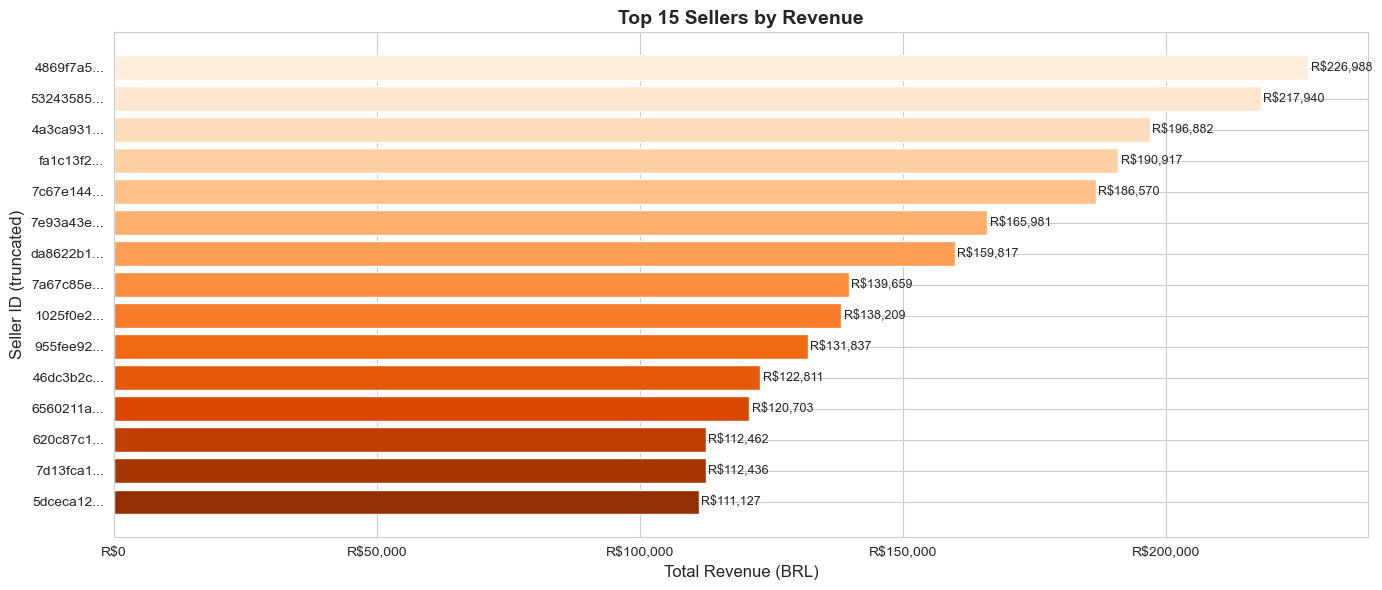

✅ Chart saved: top_sellers_revenue.png

🔹 Top 15 Sellers by Order Count:
   seller_short  order_id
0   6560211a...      1996
1   4a3ca931...      1949
2   1f50f920...      1926
3   cc419e06...      1719
4   da8622b1...      1548
5   955fee92...      1472
6   1025f0e2...      1420
7   7c67e144...      1355
8   ea8482cd...      1188
9   7a67c85e...      1155
10  4869f7a5...      1148
11  3d871de0...      1131
12  8b321bb6...      1005
13  cca3071e...       817
14  620c87c1...       778


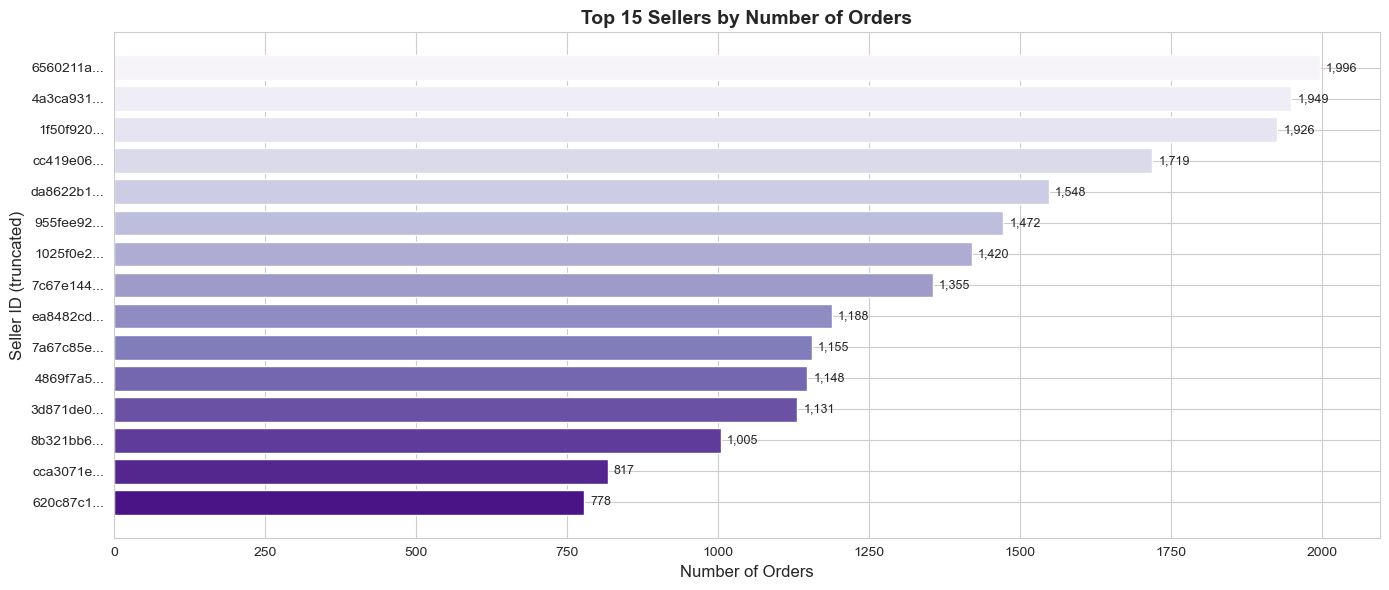

✅ Chart saved: top_sellers_orders.png


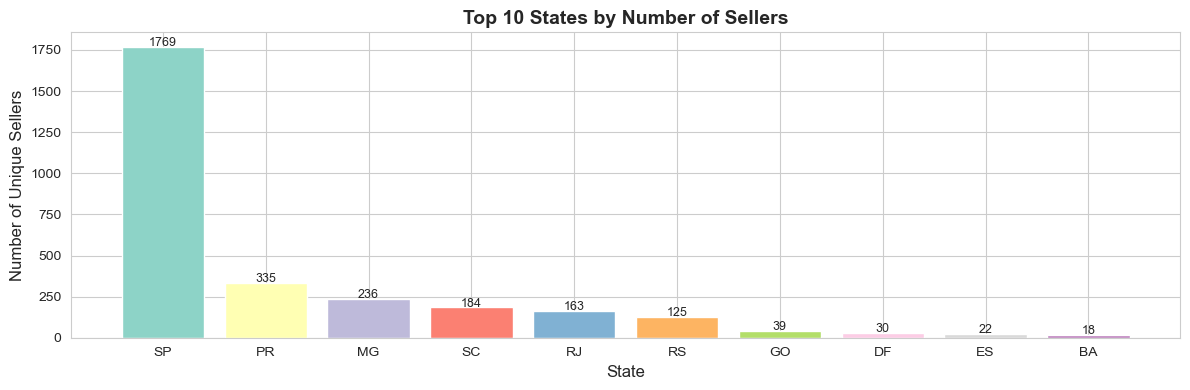

✅ Chart saved: seller_state_distribution.png


In [10]:
# ============================================================
# CELL 10: STEP 5 — EDA: Seller Analysis
# ============================================================

print("=" * 55)
print("  📊 SELLER ANALYSIS")
print("=" * 55)

# ── 1. Top 15 Sellers by Revenue ─────────────────────────────
seller_revenue = (
    product_analysis.groupby('seller_id')['price']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
seller_revenue['seller_short'] = seller_revenue['seller_id'].str[:8] + '...'
print("\n🔹 Top 15 Sellers by Revenue:")
print(seller_revenue[['seller_short', 'price']])

plt.figure(figsize=(14, 6))
bars = plt.barh(seller_revenue['seller_short'][::-1],
                seller_revenue['price'][::-1],
                color=sns.color_palette("Oranges_r", 15), edgecolor='white')
plt.title('Top 15 Sellers by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Seller ID (truncated)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
for bar in bars:
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'R${bar.get_width():,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_sellers_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: top_sellers_revenue.png")

# ── 2. Top 15 Sellers by Order Count ─────────────────────────
seller_orders = (
    product_analysis.groupby('seller_id')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
seller_orders['seller_short'] = seller_orders['seller_id'].str[:8] + '...'
print("\n🔹 Top 15 Sellers by Order Count:")
print(seller_orders[['seller_short', 'order_id']])

plt.figure(figsize=(14, 6))
bars = plt.barh(seller_orders['seller_short'][::-1],
                seller_orders['order_id'][::-1],
                color=sns.color_palette("Purples_r", 15), edgecolor='white')
plt.title('Top 15 Sellers by Number of Orders', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Seller ID (truncated)')
for bar in bars:
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_sellers_orders.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: top_sellers_orders.png")

# ── 3. Seller State Distribution ─────────────────────────────
seller_state = (
    product_analysis.groupby('seller_state')['seller_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12, 4))
bars = plt.bar(seller_state.index, seller_state.values,
               color=sns.color_palette("Set3", len(seller_state)), edgecolor='white')
plt.title('Top 10 States by Number of Sellers', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Unique Sellers')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(int(bar.get_height())),
             ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('seller_state_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: seller_state_distribution.png")

  📊 REVIEW & SATISFACTION ANALYSIS

🔹 Review Score Distribution:
review_score
1    11282
2     3114
3     8097
4    19007
5    56910
Name: count, dtype: int64


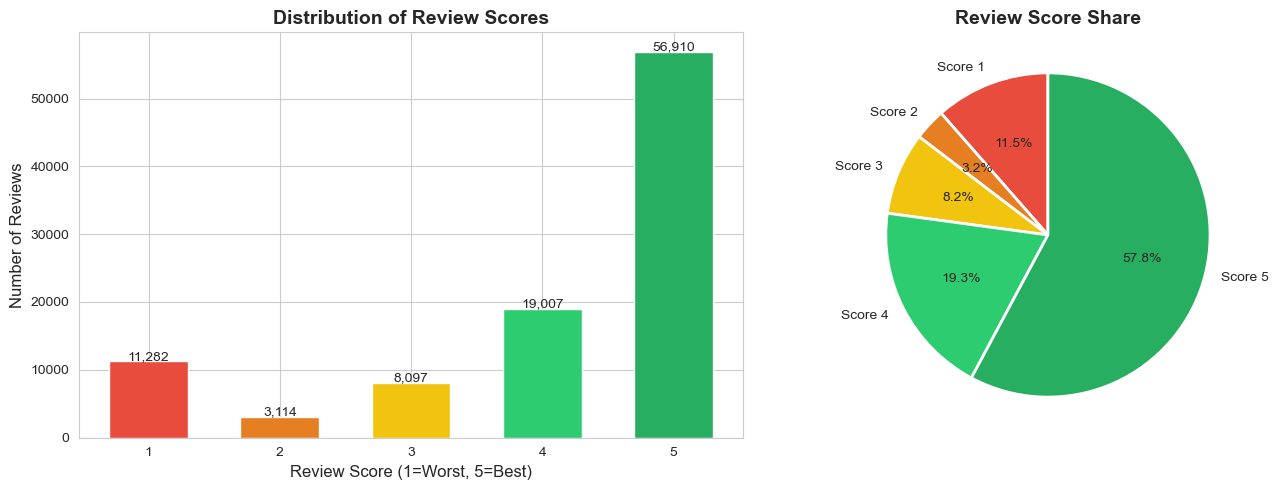

✅ Chart saved: review_score_distribution.png

🔹 Average Delivery Days by Review Score:
review_score
1.00   20.90
1.50   19.40
2.00   16.20
2.50   15.67
3.00   13.79
3.50   15.64
4.00   11.84
4.50   11.72
5.00   10.21
Name: delivery_days, dtype: float64


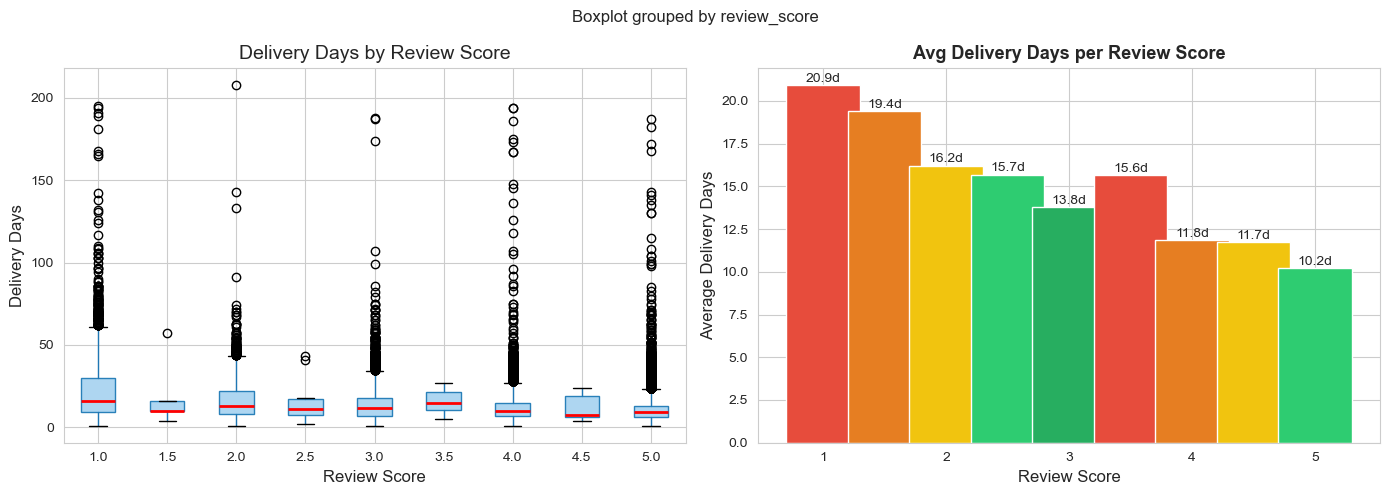

✅ Chart saved: delivery_vs_review.png

🔹 Average Review Score — On-Time vs Late:
delivery_status
Late            2.27
On-Time/Early   4.21
Name: review_score, dtype: float64


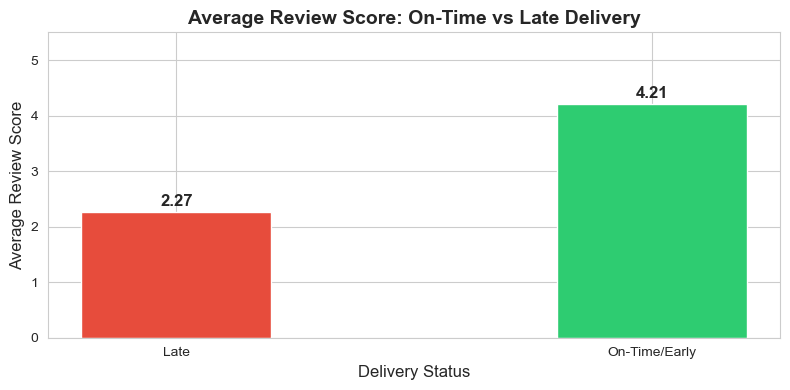

✅ Chart saved: lateness_vs_review.png


In [11]:
# ============================================================
# CELL 11: STEP 5 — EDA: Review & Satisfaction Analysis
# ============================================================

print("=" * 55)
print("  📊 REVIEW & SATISFACTION ANALYSIS")
print("=" * 55)

# ── 1. Distribution of Review Scores ─────────────────────────
review_dist = reviews['review_score'].value_counts().sort_index()
print("\n🔹 Review Score Distribution:")
print(review_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0].bar(review_dist.index, review_dist.values,
            color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Distribution of Review Scores', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Review Score (1=Worst, 5=Best)')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(review_dist.values):
    axes[0].text(review_dist.index[i], v + 200, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(review_dist.values,
            labels=[f'Score {i}' for i in review_dist.index],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Review Score Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('review_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: review_score_distribution.png")

# ── 2. Delivery Time vs Review Score ─────────────────────────
delivery_review = master[
    master['delivery_days'].notna() &
    master['review_score'].notna()
][['delivery_days', 'review_score']].copy()

delivery_review = delivery_review[delivery_review['delivery_days'] > 0]

avg_delivery_by_score = delivery_review.groupby('review_score')['delivery_days'].mean()
print("\n🔹 Average Delivery Days by Review Score:")
print(avg_delivery_by_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
delivery_review.boxplot(column='delivery_days', by='review_score', ax=axes[0],
                        patch_artist=True,
                        boxprops=dict(facecolor='#AED6F1', color='#2980B9'),
                        medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Delivery Days by Review Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Delivery Days')
plt.sca(axes[0])
plt.title('Delivery Days by Review Score')

# Bar plot — average
axes[1].bar(avg_delivery_by_score.index, avg_delivery_by_score.values,
            color=colors, edgecolor='white', width=0.6)
axes[1].set_title('Avg Delivery Days per Review Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Average Delivery Days')
for i, v in zip(avg_delivery_by_score.index, avg_delivery_by_score.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}d', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('delivery_vs_review.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: delivery_vs_review.png")

# ── 3. Late Delivery Impact on Satisfaction ───────────────────
late_review = master[master['is_late'].notna() & master['review_score'].notna()].copy()
late_review['delivery_status'] = late_review['is_late'].map({1: 'Late', 0: 'On-Time/Early'})

avg_score_by_lateness = late_review.groupby('delivery_status')['review_score'].mean()
print("\n🔹 Average Review Score — On-Time vs Late:")
print(avg_score_by_lateness)

plt.figure(figsize=(8, 4))
plt.bar(avg_score_by_lateness.index, avg_score_by_lateness.values,
        color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.4)
plt.title('Average Review Score: On-Time vs Late Delivery', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.ylim(0, 5.5)
for i, v in enumerate(avg_score_by_lateness.values):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('lateness_vs_review.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: lateness_vs_review.png")

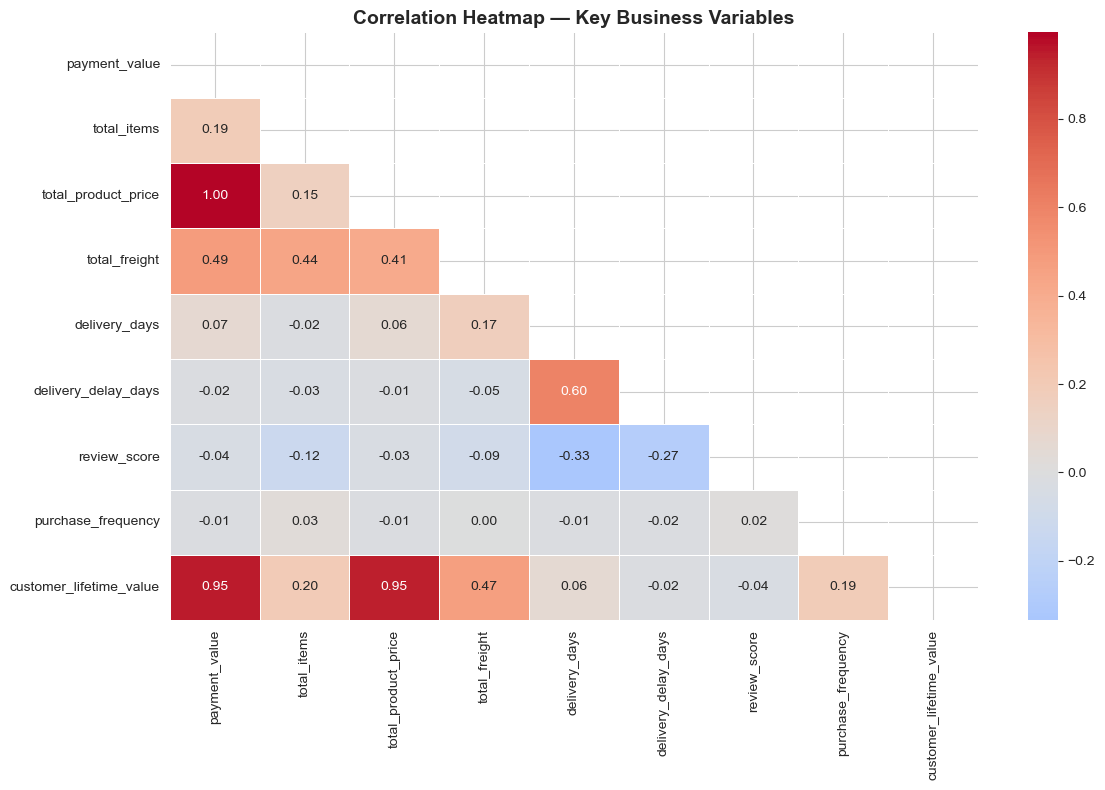

✅ Chart saved: correlation_heatmap.png

🔹 Payment Type Distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


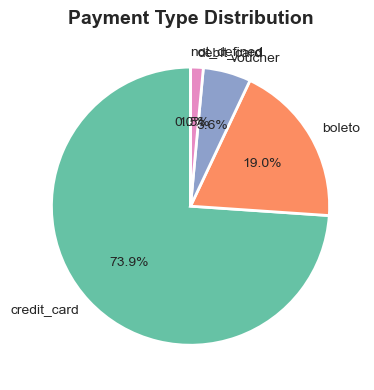

✅ Chart saved: payment_type_distribution.png


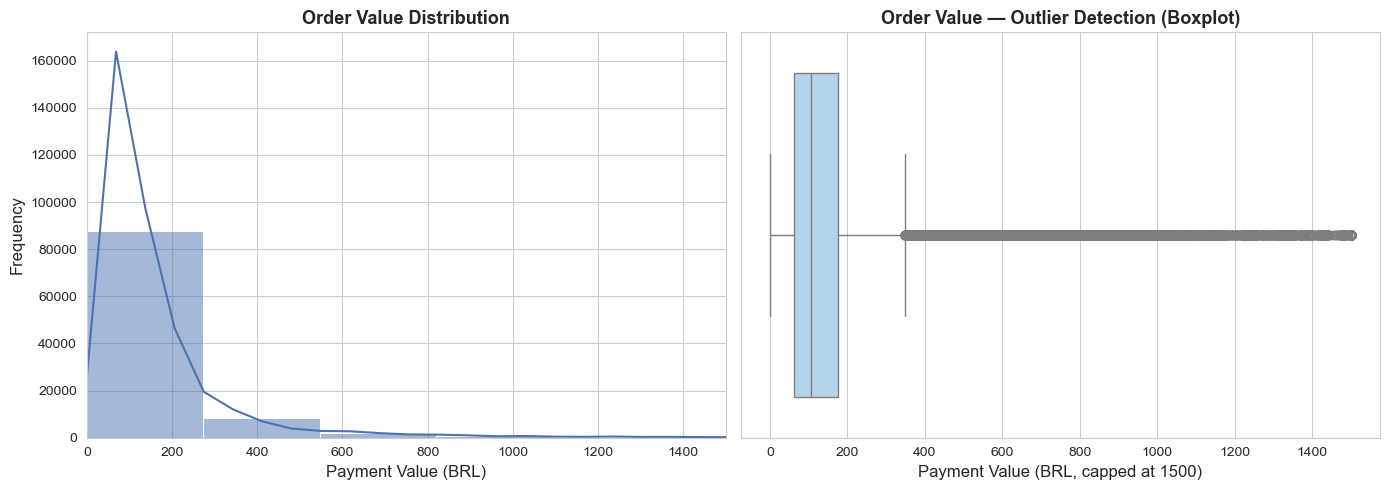

✅ Chart saved: order_value_distribution.png


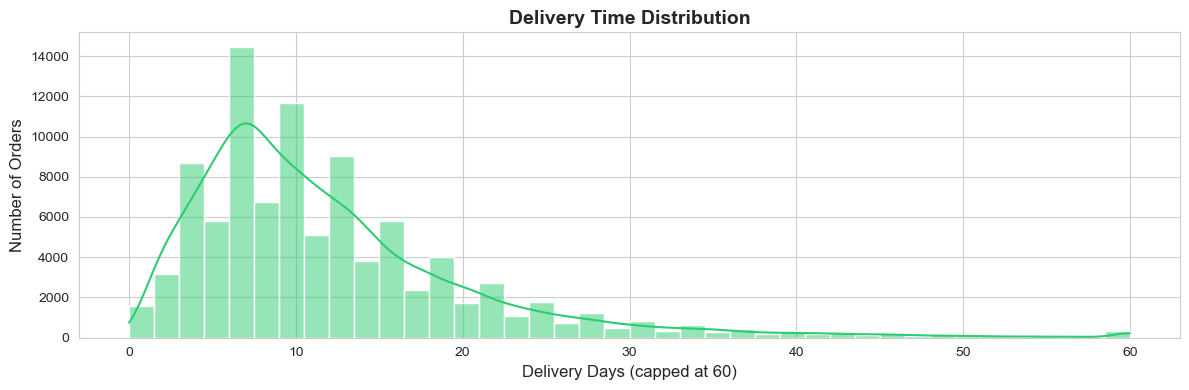

✅ Chart saved: delivery_days_distribution.png


In [12]:
# ============================================================
# CELL 12: STEP 6 — Correlation Heatmap & Summary Visuals
# ============================================================

# ── 1. Correlation Heatmap ────────────────────────────────────
corr_cols = [
    'payment_value', 'total_items', 'total_product_price',
    'total_freight', 'delivery_days', 'delivery_delay_days',
    'review_score', 'purchase_frequency', 'customer_lifetime_value'
]
corr_data = master[corr_cols].dropna()
corr_matrix = corr_data.corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 10}
)
plt.title('Correlation Heatmap — Key Business Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: correlation_heatmap.png")

# ── 2. Payment Type Distribution ─────────────────────────────
payment_type_dist = payments['payment_type'].value_counts()
print("\n🔹 Payment Type Distribution:")
print(payment_type_dist)

plt.figure(figsize=(10, 4))
plt.pie(
    payment_type_dist.values,
    labels=payment_type_dist.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("Set2", len(payment_type_dist)),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Payment Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('payment_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: payment_type_distribution.png")

# ── 3. Order Value Distribution (Histogram + Boxplot) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    master['payment_value'].dropna(),
    bins=50, kde=True, color='#4C72B0', ax=axes[0]
)
axes[0].set_title('Order Value Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Payment Value (BRL)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 1500)

sns.boxplot(
    x=master['payment_value'].dropna().clip(upper=1500),
    color='#AED6F1', ax=axes[1]
)
axes[1].set_title('Order Value — Outlier Detection (Boxplot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Payment Value (BRL, capped at 1500)')

plt.tight_layout()
plt.savefig('order_value_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: order_value_distribution.png")

# ── 4. Delivery Days Distribution ────────────────────────────
plt.figure(figsize=(12, 4))
sns.histplot(
    master['delivery_days'].dropna().clip(upper=60),
    bins=40, kde=True, color='#2ecc71'
)
plt.title('Delivery Time Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Days (capped at 60)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('delivery_days_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: delivery_days_distribution.png")

# 📊 Step 7: Business Insights & Recommendations

## 🔑 Key Findings

### 1. Customer Behavior
- The vast majority of customers are **one-time buyers**, indicating low repeat purchase rates.
- A small segment of **high-value customers** contributes disproportionately to total revenue.
- **São Paulo (SP)** dominates customer geography, followed by Rio de Janeiro (RJ) and Minas Gerais (MG).

### 2. Revenue & Orders
- Revenue showed a **strong upward trend** from 2017 to mid-2018, followed by a decline.
- A clear **peak sales period** is visible — likely driven by seasonal events or promotions.
- **Delivered orders** account for almost all revenue, confirming operational reliability for completed orders.

### 3. Product Performance
- Categories like **bed/bath/table**, **health & beauty**, and **computers accessories** are top revenue drivers.
- High-demand categories do not always correspond to high revenue — **freight and price per unit** matter.

### 4. Seller Performance
- Revenue is highly concentrated — a small group of **top sellers** drives the majority of sales.
- Most sellers are based in **São Paulo state**, creating a geographic concentration risk.

### 5. Delivery & Satisfaction
- **Lower review scores (1–2) are strongly associated with longer delivery times.**
- Late deliveries receive significantly lower satisfaction ratings on average.
- On-time or early deliveries consistently score **4–5 stars**.

---

## 💡 Strategic Recommendations

| # | Recommendation | Business Impact |
|---|----------------|-----------------|
| 1 | **Launch loyalty/retention programs** to convert one-time buyers into repeat customers | ↑ CLV, ↑ Revenue |
| 2 | **Improve last-mile delivery speed**, especially for states outside SP | ↑ Satisfaction, ↓ Returns |
| 3 | **Invest in top-performing categories** (health & beauty, electronics) with targeted promotions | ↑ GMV |
| 4 | **Diversify seller base geographically** to reduce dependency on SP sellers | ↓ Supply Risk |
| 5 | **Incentivize high-value customers** with exclusive deals and early access | ↑ Retention |
| 6 | **Monitor and flag delayed orders proactively** to reduce negative reviews | ↑ NPS |
| 7 | **Promote credit card installment plans** — most customers prefer installments | ↑ Conversion |

In [1]:
# ============================================================
# CELL 13: STEP 7 — Business Insights & Recommendations
# ============================================================

insights = """
╔══════════════════════════════════════════════════════════╗
║        BUSINESS INSIGHTS & RECOMMENDATIONS               ║
╚══════════════════════════════════════════════════════════╝

KEY FINDINGS:
─────────────────────────────────────────────────────────
1. CUSTOMER BEHAVIOR
   - Majority of customers are one-time buyers (low retention)
   - Small high-value segment contributes most revenue
   - Sao Paulo (SP) dominates customer geography

2. REVENUE & ORDERS
   - Strong upward revenue trend from 2017 to mid-2018
   - Clear peak sales periods driven by seasonal demand
   - Delivered orders account for almost all revenue

3. PRODUCT PERFORMANCE
   - Top categories: bed/bath/table, health & beauty, computers
   - High demand does not always mean high revenue per category
   - Freight value plays a major role in total order value

4. SELLER PERFORMANCE
   - Revenue concentrated among a small group of top sellers
   - Most sellers based in SP -- geographic concentration risk

5. DELIVERY & SATISFACTION
   - Low review scores (1-2) linked to longer delivery times
   - Late deliveries average significantly lower ratings
   - On-time/early deliveries consistently score 4-5 stars

STRATEGIC RECOMMENDATIONS:
─────────────────────────────────────────────────────────
   1. Launch loyalty programs to convert one-time buyers
      Impact: Higher CLV and repeat revenue

   2. Improve last-mile delivery speed outside SP state
      Impact: Higher satisfaction scores, fewer complaints

   3. Invest in top categories with targeted promotions
      Impact: Higher Gross Merchandise Value (GMV)

   4. Diversify seller base geographically
      Impact: Reduced supply chain risk

   5. Incentivize high-value customers with exclusive deals
      Impact: Higher retention rate

   6. Proactively flag and escalate delayed orders
      Impact: Fewer negative reviews, better NPS

   7. Promote credit card installment payment options
      Impact: Higher conversion rate
"""

print(insights)


╔══════════════════════════════════════════════════════════╗
║        BUSINESS INSIGHTS & RECOMMENDATIONS               ║
╚══════════════════════════════════════════════════════════╝

KEY FINDINGS:
─────────────────────────────────────────────────────────
1. CUSTOMER BEHAVIOR
   - Majority of customers are one-time buyers (low retention)
   - Small high-value segment contributes most revenue
   - Sao Paulo (SP) dominates customer geography

2. REVENUE & ORDERS
   - Strong upward revenue trend from 2017 to mid-2018
   - Clear peak sales periods driven by seasonal demand
   - Delivered orders account for almost all revenue

3. PRODUCT PERFORMANCE
   - Top categories: bed/bath/table, health & beauty, computers
   - High demand does not always mean high revenue per category
   - Freight value plays a major role in total order value

4. SELLER PERFORMANCE
   - Revenue concentrated among a small group of top sellers
   - Most sellers based in SP -- geographic concentration risk

5. DELIVERY

In [14]:
# ============================================================
# CELL 14: Final Project Summary
# ============================================================

print("=" * 60)
print("  ✅ PROJECT COMPLETE — SUMMARY STATISTICS")
print("=" * 60)

print(f"\n📦 Total Orders Analyzed       : {master.shape[0]:,}")
print(f"👥 Unique Customers            : {master['customer_unique_id'].nunique():,}")
print(f"🏪 Unique Sellers              : {order_items_full['seller_id'].nunique():,}")
print(f"🛍️  Unique Products             : {order_items_full['product_id'].nunique():,}")
print(f"💰 Total Revenue (BRL)         : R${master['payment_value'].sum():,.2f}")
print(f"⭐ Average Review Score        : {master['review_score'].mean():.2f} / 5.0")
print(f"🚚 Average Delivery Days       : {master['delivery_days'].mean():.1f} days")
print(f"🔁 Repeat Customer Rate        : {(master.drop_duplicates('customer_unique_id')['customer_type']=='Repeat').mean()*100:.1f}%")
print(f"⏰ On-Time Delivery Rate       : {(master['is_late']==0).mean()*100:.1f}%")
print(f"\n✅ All charts saved as PNG files in your notebook folder.")
print("=" * 60)

  ✅ PROJECT COMPLETE — SUMMARY STATISTICS

📦 Total Orders Analyzed       : 99,441
👥 Unique Customers            : 96,096
🏪 Unique Sellers              : 3,095
🛍️  Unique Products             : 32,951
💰 Total Revenue (BRL)         : R$16,008,872.12
⭐ Average Review Score        : 4.09 / 5.0
🚚 Average Delivery Days       : 12.1 days
🔁 Repeat Customer Rate        : 3.1%
⏰ On-Time Delivery Rate       : 93.4%

✅ All charts saved as PNG files in your notebook folder.
